In [1]:
import os
os.chdir('../../../..')

In [2]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from umap import UMAP

from src.datasets import QM9Dataset
from scripts.materials_project.euclidean_evaluation_pipeline import build_invariant_matrix
from src.helper_functions import create_chemiscope_viewer

In [3]:
qm9 = QM9Dataset(limit=None, stratify_by=['num_atoms', 'gap'], sampling_strategy="stratified")
df = qm9.load()

limit = None
formula_counts = df.group_by("formula").len().sort("len", descending=True)

eligible = formula_counts.filter(pl.col("len") >= 1000)
#if eligible.is_empty():
#    raise ValueError(f"No formulas found with at least {limit} isomers")

target_formula = eligible.row(0)[0]

isomers_df = df.filter(pl.col("formula") == target_formula)
df = isomers_df

2026-04-07 11:34:12.624 | INFO     | src.datasets:load:485 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-07 11:34:12.853 | INFO     | src.datasets:_sample_qm9_df:601 - QM9 sampling complete: strategy=stratified, requested_limit=None, returned_rows=122608.
2026-04-07 11:34:12.854 | INFO     | src.datasets:_add_requested_descriptors:125 - Applying requested QM9 descriptors to sampled dataframe (rows=122608).
2026-04-07 11:34:12.854 | INFO     | src.datasets:_add_requested_descriptors:150 - No new descriptor columns added (already present or none requested).


In [4]:
print(df.shape)

(5525, 60)


In [5]:
features_1 = ['ea']
features_2 = ['en', 'ion_en']
features_3 = ['en']
features_4 = ['ion_en', 'z', 'en']
features_5 = ['coord', 'ea']
features_6 = ['z', 'rad', 'mendeleev', 'ea']

raw_matrix_1 = build_invariant_matrix(df, aggregated=True, feature_keys=features_1)
raw_matrix_2 = build_invariant_matrix(df, aggregated=True, feature_keys=features_2)
raw_matrix_3 = build_invariant_matrix(df, aggregated=True, feature_keys=features_3)
raw_matrix_4 = build_invariant_matrix(df, aggregated=True, feature_keys=features_4)
raw_matrix_5 = build_invariant_matrix(df, aggregated=True, feature_keys=features_5)
raw_matrix_6 = build_invariant_matrix(df, aggregated=True, feature_keys=features_6)

scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(raw_matrix_1)
scaled_matrix_2 = scaler.fit_transform(raw_matrix_2)
scaled_matrix_3 = scaler.fit_transform(raw_matrix_3)
scaled_matrix_4 = scaler.fit_transform(raw_matrix_4)
scaled_matrix_5 = scaler.fit_transform(raw_matrix_5)
scaled_matrix_6 = scaler.fit_transform(raw_matrix_6)

Evaluating KMeans for different cluster counts:   0%|          | 0/9 [00:00<?, ?it/s]

Evaluating KMeans for different cluster counts:  67%|██████▋   | 6/9 [00:05<00:02,  1.11it/s]/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
Evaluating KMeans for different cluster counts:  78%|███████▊  | 7/9 [00:06<00:01,  1.22it/s]/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
Evaluating KMeans for different cluster counts:  89%|████████▉ | 8/9 [00:07<00:00,  1.33it/s]/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/

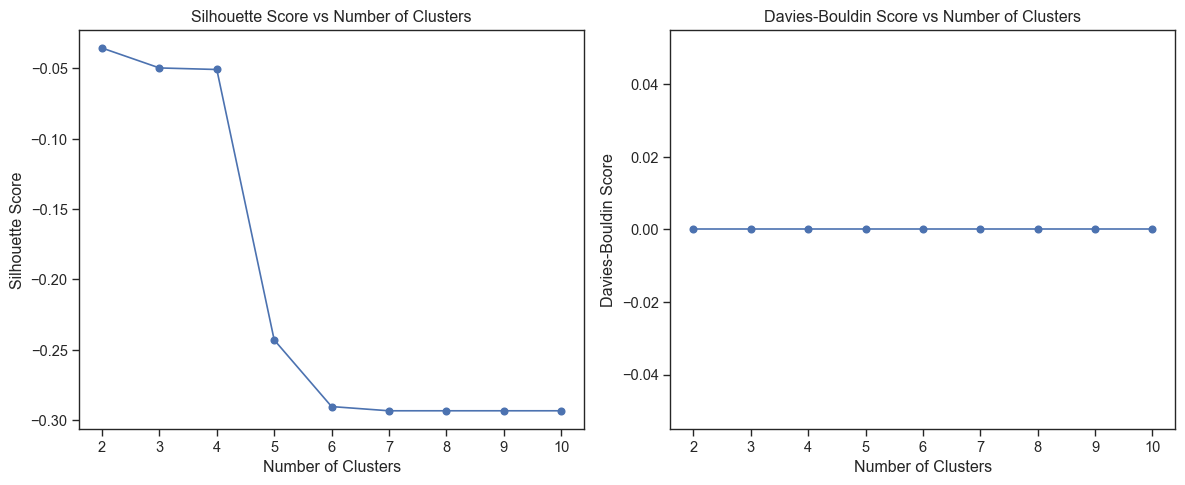

In [12]:
sil_scores = []
db_scores = []

for i in tqdm(range(2, 11), desc="Evaluating KMeans for different cluster counts"):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(scaled_matrix_6)
    sil = silhouette_score(scaled_matrix_5, labels)
    db = davies_bouldin_score(scaled_matrix_6, labels)
    sil_scores.append(sil)
    db_scores.append(db)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), sil_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), db_scores, marker='o')
plt.title('Davies-Bouldin Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Score')
plt.tight_layout()
plt.show()

In [14]:
best_k = 3

labels = KMeans(n_clusters=best_k, random_state=42, n_init='auto').fit_predict(scaled_matrix_6)
df = df.with_columns(pl.Series("cluster_label", labels))

sil = silhouette_score(scaled_matrix_6, labels)
db = davies_bouldin_score(scaled_matrix_6, labels)
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")

Silhouette Score: 0.9459
Davies-Bouldin Score: 0.0000


In [ ]:
reducer = 'PCA'
create_chemiscope_viewer(df, scaled_matrix_6, labels=labels, reduction_method=reducer)

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

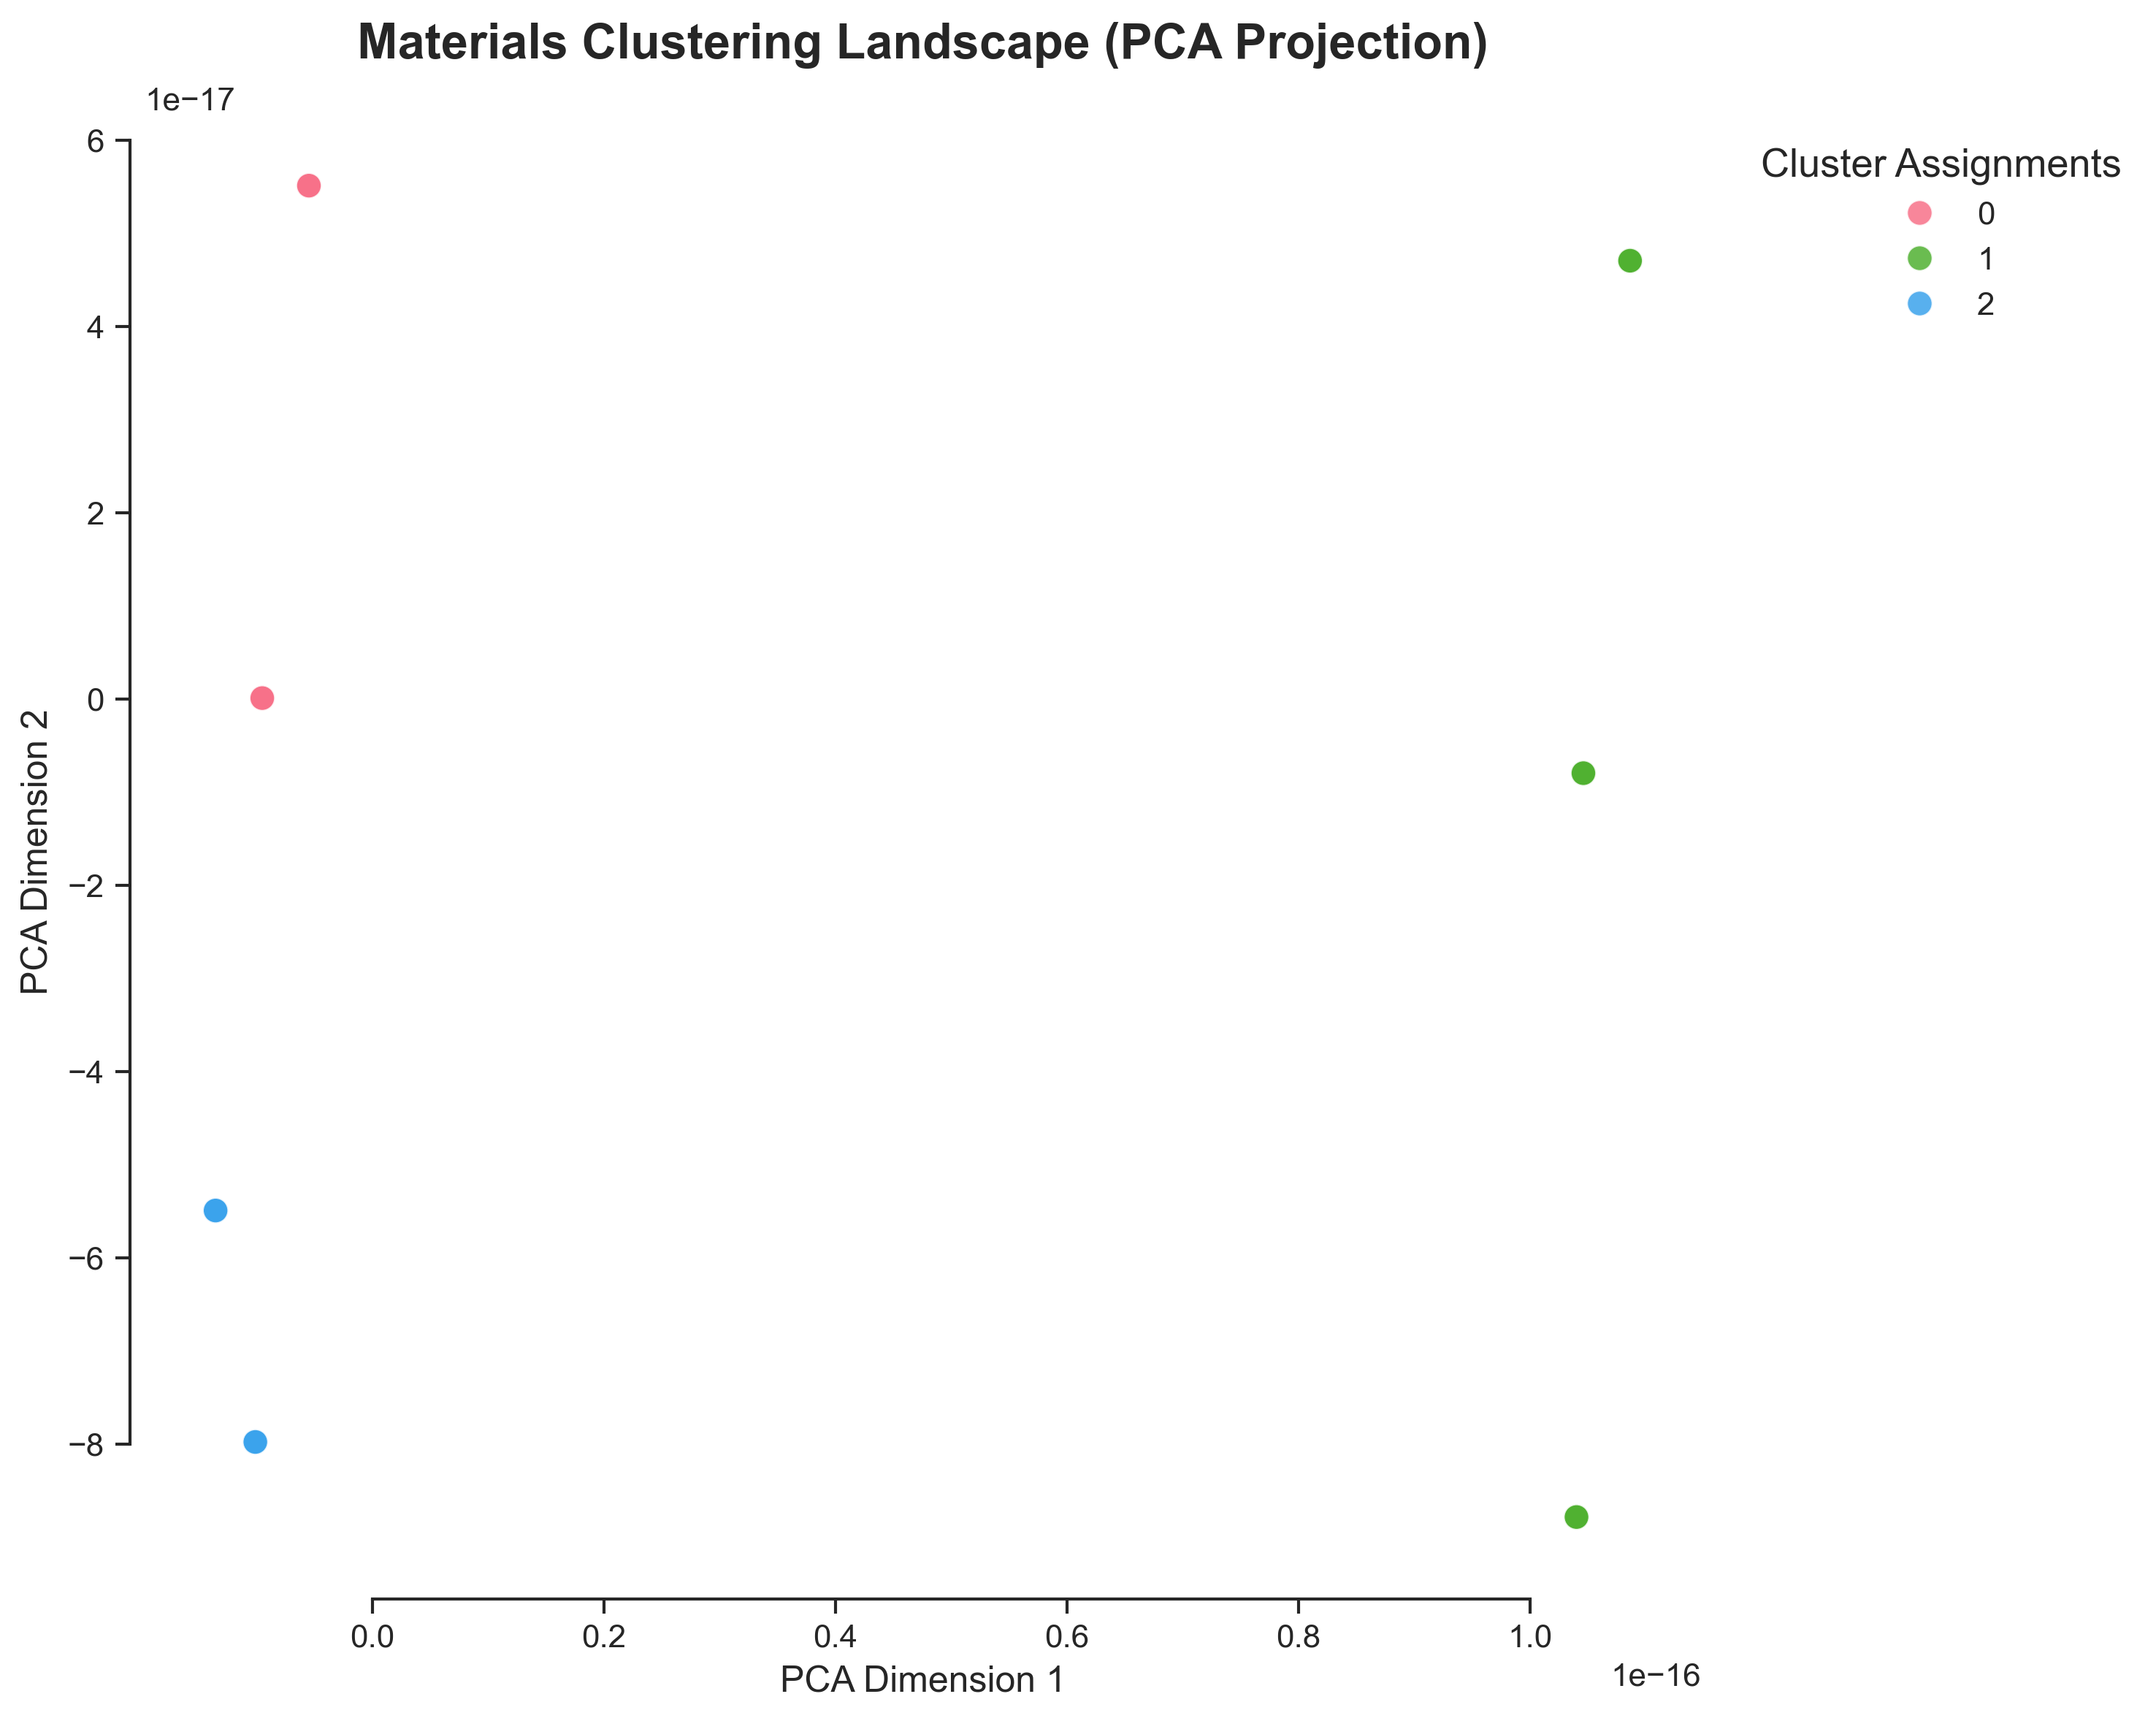

In [16]:
# pca reducer
pca_reducer = PCA(n_components=2, random_state=42)
pca_embedding = pca_reducer.fit_transform(scaled_matrix_6)

# 2. Setup Professional Plot Style
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 8), dpi=300) # High DPI makes it crisp for papers/presentations

# Convert labels to numpy array for boolean masking
labels = np.array(labels)
unique_labels = np.unique(labels)
n_clusters = len([l for l in unique_labels if l != -1])

# 3. Plot Noise First (so it stays in the background!)
noise_mask = (labels == -1)
if noise_mask.any():
    ax.scatter(
        pca_embedding[noise_mask, 0], 
        pca_embedding[noise_mask, 1], 
        c='#B0B0B0',        # Soft silver/grey
        s=15,               # Smaller size
        alpha=0.4,          # Highly transparent
        label='Noise (-1)',
        edgecolors='none'
    )

# 4. Plot the Valid Clusters
cluster_mask = (labels != -1)
if cluster_mask.any():
    # Use a vibrant, visually pleasing palette
    palette = sns.color_palette("husl", n_clusters)
    
    sns.scatterplot(
        x=pca_embedding[cluster_mask, 0], 
        y=pca_embedding[cluster_mask, 1], 
        hue=labels[cluster_mask], 
        palette=palette,
        s=70,               # Larger size for valid points
        alpha=0.85,         # Slight transparency to show density
        edgecolor='white',  # Adds a crisp outline to overlapping points
        linewidth=0.6,
        ax=ax,
        legend='full'
    )

# 5. Typography and Labels
ax.set_title('Materials Clustering Landscape (PCA Projection)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('PCA Dimension 1', fontsize=12, fontweight='medium')
ax.set_ylabel('PCA Dimension 2', fontsize=12, fontweight='medium')

# 6. Clean up the box/axes (Despine)
sns.despine(trim=True, offset=5)

# 7. Legend Formatting
# Move legend outside the plot, remove its ugly box
ax.legend(title="Cluster Assignments", 
          bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          frameon=False, 
          title_fontsize='13')

plt.tight_layout()

# Save it as a high-quality image (optional)
plt.savefig("figures/qm9/clustering/kmeans/pca_clusters.png", dpi=300, bbox_inches='tight')

plt.show()

In [10]:
def average_numeric_by_cluster(df: pl.DataFrame) -> pl.DataFrame:
    """
    Groups a Polars DataFrame by 'cluster_label' and returns 
    the mean of all numeric columns.
    """
    return (
        df.group_by("cluster_label")
        .agg(
            pl.col(pl.NUMERIC_DTYPES).mean()
        )
        .sort("cluster_label")
    )

cluster_averages = average_numeric_by_cluster(df)
with pl.Config(set_tbl_cols=-1, set_tbl_width_chars=1000, set_tbl_rows=-1):
    print(cluster_averages)

shape: (3, 54)
┌───────────────┬───────────┬────────────┬──────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬──────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬──────────┐
│ cluster_label ┆ num_atoms ┆ mol_weight ┆ logp     ┆ tpsa      ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ num_rings ┆ num_aromatic_rings ┆ coordination ┆ num_rotatable_bonds ┆ f

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_39988/569150655.py:9: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).mean()
